In [12]:
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
import torch.nn as nn
import math
import numpy as np
from tqdm import tqdm
from pyhdf.SD import SD, SDC
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats

from os.path import join as path_join
from scipy.ndimage import zoom
import os
from scipy.interpolate import RegularGridInterpolator
import gc

FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]
# FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf"]
DEFAULT_RESOLUTIONS = ['medium', 'high']
BASE_DIR =  '../../sample_cr_data'
component_list = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]
PER_SAMPLE_PER_COMPONENT_METRICS = ['MSE','PSNR','UQI', 'NNSE', 'EMV', 'ACC']
import pandas as pd
import seaborn as sns

In [34]:


FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf", "jt002.hdf", "jp002.hdf", "jr002.hdf", "rho002.hdf", "p002.hdf"]
# FILE_NAMES = ["vr002.hdf", "br002.hdf", "vt002.hdf", "vp002.hdf", "bt002.hdf", "bp002.hdf"]
DEFAULT_RESOLUTIONS = ['medium', 'high']

DEFAULT_INSTRUMENTS = [
    "kpo_mas_mas_std_0101",
    "mdi_mas_mas_std_0101",
    "hmi_mast_mas_std_0101",
    "hmi_mast_mas_std_0201",
    "hmi_masp_mas_std_0201",
    "mdi_mas_mas_std_0201",
]


def read_hdf(hdf_path, dataset_names):
    f = SD(hdf_path, SDC.READ)
    datasets = []
    for dataset_name in dataset_names:
        datasets.append(f.select(dataset_name).get())
    return datasets


def get_coords(sim_path):
    v_path = path_join(sim_path, FILE_NAMES[0])
    thetas, phis = read_hdf(v_path, ["fakeDim1", "fakeDim0"])
    return thetas, phis

def interpolate_cube(data, x_old, y_old, z_old, x_new, y_new, z_new):
    interp_func = RegularGridInterpolator(
        (x_old, y_old, z_old),
        data,
        method="linear",
        bounds_error=False,
        fill_value=None,
    )
    xg, yg, zg = np.meshgrid(x_new, y_new, z_new, indexing="ij")
    points_new = np.stack([xg.ravel(), yg.ravel(), zg.ravel()], axis=-1)
    data_new_flat = interp_func(points_new)
    data_new = data_new_flat.reshape((len(x_new), len(y_new), len(z_new)))
    return data_new

def read_sim(sim_path):
    dataset_names = ["Data-Set-2", "fakeDim0", "fakeDim1", "fakeDim2"]
    component_dict = {k.split('002')[0]:{} for k in FILE_NAMES}
    target_phi, target_theta, target_r = [None]*3
    for file_name in FILE_NAMES:
        data, phi, theta, r = read_hdf(f"{sim_path}/{file_name}", dataset_names) 
        comp = file_name.split('002')[0]
        component_dict[comp] = {
            'data': data[:,:, :3],
            'theta': theta,
            'r': r[:3],
            'phi': phi,
        }
        if comp == 'vp':
            target_r = np.array([r[1]], dtype=r.dtype) # [30.742662]
            target_theta = theta
            target_phi = phi
            
    return (component_dict, target_r, target_theta, target_phi)

def read_medium_target_grid(medium_ref_path="../../sample_cr_data/medium/cr1625/kpo_mas_mas_std_0101"):
    _, target_r, target_theta, target_phi = read_sim(medium_ref_path)

    return target_r, target_theta, target_phi
    
def get_sim(sim_path, scale_up):
    
    component_list = [k.split('002')[0] for k in FILE_NAMES]
    out,_,_,_= read_sim(sim_path)
    target_r, target_theta, target_phi = read_medium_target_grid()
    final = dict()
    for component in component_list:
        
        data_old, theta_old, r_old, phi_old = (
            out[component]["data"],
            out[component]["theta"],
            out[component]["r"],
            out[component]["phi"],
        )
        # print(f'{component}: Before Interpolation shape: {data_old.shape}')
        data_new = interpolate_cube(data_old, phi_old, theta_old, r_old, target_phi, target_theta, target_r)
        data_new = np.transpose(data_new, (2, 1, 0))  # (r, theta, phi)
        # print(f'{component}: After Interpolation shape: {data_new.shape}')
        final[component] = data_new[0,1:-1,:]
        # print(f'{component}: After Cropping shape: {final[component].shape}')

    final_component_arr = np.array([final[comp] for comp in component_list])
    
    if scale_up != 1:
        final_component_arr = enlarge_cube(final_component_arr, scale_up)

    return final_component_arr, (target_r, target_theta[1:-1], target_phi)


def get_sims(sim_paths, scale_up, pos_emb = None):
    sims = []

    for sim_path in tqdm(sim_paths, desc="Loading simulations"):
        sim, _ = get_sim(sim_path, scale_up)  # (140, 111, 128)
        sims.append(sim)

    sims = np.stack(sims, axis=0)  # (N, 11, 111, 128)
    return sims



def enlarge_cube(cube, scale):
    """
    Enlarge the spatial dimensions (axis 2 and 3) of a 4D cube using bilinear interpolation.

    Parameters:
    - cube: np.ndarray of shape (11, 110, 128)
    - scale: int or float (e.g., 2)

    Returns:
    - enlarged_cube: np.ndarray of shape (11, 110 * scale, 128 * scale)
    """
    return zoom(cube, (1, scale, scale), order=1)

def signed_sqrt_transform(array):
    return np.sign(array) * (np.abs(array)**0.5)

def signed_pow_transform(array, power):
    return np.sign(array) * (np.abs(array)**power)

def signed_log_transform(array):
    return np.sign(array) * np.log(np.abs(array)+1)

# def arcsinh_transform(array):
#     return np.arcsinh(array)
#     import torch

def arcsinh_transform(array: np.ndarray, scale: torch.Tensor, eps: float = 1e-16):
    """
    Arcsinh transform with component-wise scale.

    x:     tensor of shape (B, C, H, W) or similar
    scale: tensor of shape (C,) or broadcastable to x
    """
    scale = np.asarray(scale, dtype=array.dtype)

    if scale.ndim == 1:
        if array.ndim == 4:      # (N, C, H, W)
            scale = scale.reshape(1, -1, 1, 1)
        elif array.ndim == 3:    # (C, H, W)
            scale = scale.reshape(-1, 1, 1)

    return np.arcsinh(array / (scale + eps))
 
def sinh_arcsinh_transform(array, epsilon=0.0, delta=1.0):
    """
    Sinh-arcsinh transformation.

    epsilon controls skewness.
    delta controls tail weight.

    epsilon = 0 and delta = 1 gives identity transform.
    delta > 1 reduces tail heaviness.
    delta < 1 increases tail heaviness.
    """
    return np.sinh(delta * np.arcsinh(array) - epsilon)

def signed_transform(array, transform='sqrt', power=None, epsilon=0.0, delta=1.0, scale=None):
    if transform == 'sqrt':
        return signed_sqrt_transform(array)
    elif transform == 'log':
        return signed_log_transform(array)
    elif transform == 'pow' and power is not None:
        return signed_pow_transform(array, power)
    elif transform == 'arcsinh':
        return arcsinh_transform(array, scale=scale)
    elif transform == 'sinh_arcsinh':
        return sinh_arcsinh_transform(array, epsilon=epsilon, delta=delta)
    else:
        raise ValueError("Unsupported transform type or missing power for 'pow' transform.")

def data_transformation(array, transform='sqrt', power=None, epsilon=0.0, delta=1.0, scale=None):  
    """
    :param array: (11, H, W)
    Returns: array after data transformation 
    """
    if isinstance(transform, str):
        transform = [transform] * array.shape[1]  # Apply same transform to all channels if a single string is provided
    elif isinstance(transform, list):
        assert len(transform) == array.shape[1], "Length of transform list must match number of channels in the array."
        pass
    else:
        raise ValueError("Transform must be either a string or a list of strings.")

    # VR_0 -> No transformation required
    # BR_0 -> No transformation required

    # VT_0
    array[:,2] = signed_transform(array[:,2], transform=transform[2], power=power, epsilon=epsilon, delta=delta, scale=scale[0])   # Sign-preserving data transformation
    # VP_0
    array[:,3] = signed_transform(array[:,3], transform=transform[3], power=power, epsilon=epsilon, delta=delta, scale=scale[1])   # Sign-preserving data transformation
    # BT_0
    array[:,4] = signed_transform(array[:,4], transform=transform[4], power=power, epsilon=epsilon, delta=delta, scale=scale[2] )   # Sign-preserving data transformation
    # BP_0
    array[:,5] = signed_transform(array[:,5], transform=transform[5], power=power, epsilon=epsilon, delta=delta, scale=scale[3])   # Sign-preserving data transformation
    # JT_0 -> No transformation required
    # JP_0
    array[:,7] = signed_transform(array[:,7], transform=transform[7], power=power, epsilon=epsilon, delta=delta, scale=scale[5])   # Sign-preserving data transformation
    # JR_0
    array[:,8] = signed_transform(array[:,8], transform=transform[8], power=power, epsilon=epsilon, delta=delta, scale=scale[6])   # Sign-preserving data transformation
    # RHO_0 -> No transformation required
    array[:,9] = signed_transform(array[:,9], transform=transform[9], power=power, epsilon=epsilon, delta=delta, scale=scale[7])   # Sign-preserving data transformation
    # P_0 
    array[:,10] = signed_transform(array[:,10], transform='pow', power=power, scale=scale[8])   # Sign-preserving POW(0.25) transformation
    return array


def signed_power_inverse_transform(array, power):
    return torch.sign(array) * (torch.abs(array)**power)

def signed_exp_inverse_transform(array):
    return torch.sign(array) * (torch.exp(torch.abs(array)) - 1)
# def arcsinh_inverse_transform(array):
#     return torch.sinh(array)

def arcsinh_inverse_transform(x_tf: torch.Tensor, scale: torch.Tensor):
    scale = scale.to(x_tf.device, x_tf.dtype)

    if scale.ndim == 1:
        shape = [1, -1] + [1] * (x_tf.ndim - 2)
        scale = scale.view(*shape)

    return torch.sinh(x_tf) * scale

def sinh_arcsinh_inverse_transform(array, epsilon=0.0, delta=1.0):
    return torch.sinh((torch.asinh(array) + epsilon) / delta)

def signed_inverse_transform(array, transform='square', power=None, epsilon=0.0, delta=1.0, scale=None):
    
    if transform == 'square':
        return signed_power_inverse_transform(array, power=2)
    elif transform == 'exp':
        return signed_exp_inverse_transform(array)  # Subtract 1 to reverse the +1 in the log transform
    elif transform == 'pow' and power is not None:
        return signed_power_inverse_transform(array, power=power)
    elif transform == 'sinh':
        return arcsinh_inverse_transform(array, scale=scale)
    elif transform == 'sinh_arcsinh':
        return sinh_arcsinh_inverse_transform(array, epsilon=epsilon, delta=delta)
    else:
        raise ValueError("Unsupported inverse transform type or missing power for 'pow' inverse transform.")

def data_inverse_transformation(array, inverse_transform, power=None, scale_metric=481.3711,
                                epsilon=0.0, delta=1.0, scale=None):
    """
    Differentiable inverse transform.
    Input shape: (B, 9, H, W)
    Output: physical-unit tensor
    """

    if isinstance(inverse_transform, str):
        inverse_transform = [inverse_transform] * array.shape[1]
    elif isinstance(inverse_transform, list):
        assert len(inverse_transform) == array.shape[1], (
            "Length of inverse_transform list must match number of channels."
        )
    else:
        raise ValueError("Transform must be either a string or a list of strings.")

    if scale is not None:
        scale = scale.to(array.device, array.dtype)

    channels = []

    for c in range(array.shape[1]):
        x_c = array[:, c:c+1]

        # JT channel index 4 has no inverse transform in your current logic
        if c == 4:
            channels.append(x_c)
            continue

        # P channel: force inverse power 4
        if c == 8:
            x_c = signed_inverse_transform(
                x_c,
                transform=inverse_transform[c],
                power=4,
                epsilon=epsilon,
                delta=delta,
                scale=scale[c:c+1] if scale is not None else None,
            )
        else:
            x_c = signed_inverse_transform(
                x_c,
                transform=inverse_transform[c],
                power=power,
                epsilon=epsilon,
                delta=delta,
                scale=scale[c:c+1] if scale is not None else None,
            )

        channels.append(x_c)

    array_out = torch.cat(channels, dim=1)

    return array_out * scale_metric

def min_max_normalize(array, min_=None, max_=None):
    if min_ is None or max_ is None:
        min_ = np.min(array, axis=(0,2,3))
        max_ = np.max(array, axis=(0,2,3))
    array = (array - min_[:,None, None]) / (max_[:,None, None] - min_[:,None, None] + 1e-9)
    return array, min_, max_

def min_max_denormalize(array, min_, max_):
    '''
    Denormalize the data using the provided min and max values.
    :param array: Normalized array of shape (N, 11, H, W)
    :param min_: Minimum values for each channel (shape: (11,))
    :param max_: Maximum values for each channel (shape: (11,))
    '''
    array = array * (max_[:, None, None] - min_[:, None, None] + 1e-9) + min_[:, None, None]
    return array

def compute_climatology(data: np.ndarray, scale_up) -> np.ndarray:
    """
    Compute per-voxel climatology (mean field) from a dataset.

    Args:
        data (np.ndarray): Array of shape (N, 9, 109, 128)

    Returns:
        np.ndarray: Climatology array of shape (9, 109, 128)
    """
    assert data.ndim == 4 and data.shape[1:] == (
        9,
        109 * scale_up,
        128 * scale_up,
    ), "Unexpected input shape."
    climatology = np.mean(data, axis=0)
    climatology = torch.tensor(climatology, dtype=torch.float32)
    return climatology


def get_cr_dirs(data_path, resolutions = ['medium', 'high']):
    """Return list of CR directories (crXXXX) inside data_path."""
    cr_dirs = sorted(
        [
            d
            for res in resolutions
            for d in os.listdir(os.path.join(data_path, res))
            if d.startswith("cr") and os.path.isdir(os.path.join(data_path,res, d))
        ]
    )
    return cr_dirs



def collect_sim_paths(data_path, cr_list, instruments=None, resolutions = None):
    """Collect simulation paths given a list of CR directories."""
    if instruments is None:
        instruments = DEFAULT_INSTRUMENTS
    resolutions = DEFAULT_RESOLUTIONS if resolutions is None else resolutions

    sim_paths = []
    cr_nums = []
    for res in resolutions:
        for cr in cr_list:
            cr_path = os.path.join(data_path, res, cr)
            for instrument in instruments:
                instrument_path = os.path.join(cr_path, instrument)
                if os.path.exists(instrument_path):
                    sim_paths.append(instrument_path)
                    cr_nums.append(cr)
    return sim_paths, cr_nums

def get_transform_scale(array, method="std", q=95, eps=1e-8):
    """
    array: numpy array or torch tensor with shape (N, C, H, W)
    returns: torch tensor of shape (C,)
    """
    if method is None:
        return torch.ones(array.shape[1], dtype=torch.float32)

    if isinstance(array, np.ndarray):
        if method == "std":
            scale = np.std(array, axis=(0, 2, 3))
        elif method == "percentile":
            scale = np.percentile(np.abs(array), q, axis=(0, 2, 3))
        elif method == "mean":
            scale = np.mean(np.abs(array), axis=(0, 2, 3))
        else:
            raise ValueError(f"Unknown scale method: {method}")

        scale = np.maximum(scale, eps)
        return torch.tensor(scale, dtype=torch.float32)

    elif isinstance(array, torch.Tensor):
        if method == "std":
            scale = torch.std(array, dim=(0, 2, 3))
        elif method == "percentile":
            scale = torch.quantile(
                torch.abs(array).reshape(array.shape[0], array.shape[1], -1),
                q / 100.0,
                dim=(0, 2),
            )
        elif method == "mean":
            scale = torch.mean(torch.abs(array), dim=(0, 2, 3))
        else:
            raise ValueError(f"Unknown scale method: {method}")

        return torch.clamp(scale, min=eps).float()

    else:
        raise TypeError(f"Expected numpy array or torch tensor, got {type(array)}")


TF_INV_TF_DICT = {
    'sqrt': 'square',
    'log': 'exp',
    'pow': 'pow',
    'arcsinh': 'sinh',
    'sinh_arcsinh': 'sinh_arcsinh'
    }
class InitialParamDataset(Dataset):
    def __init__(
        self,
        data_path,
        cr_list,
        v_min=None,
        v_max=None,
        instruments=None,
        scale_up=1,
        pos_embedding = None,
        transform=None,
        transform_fn = None,
        resolutions = None,
        scale = None
    ):
        super().__init__()
        self.transform = transform
        self.transform_power = None
        self.inverse_transform_power = None
        if isinstance(transform, list):
            self.transform = [None, None] + transform
            self.inverse_transform = [ TF_INV_TF_DICT[tf] for tf in self.transform[2:]]
            self.transform_power = 0.25
            self.inverse_transform_power = 4
        elif transform == 'pow':
            self.inverse_transform = 'pow'
            self.transform_power = 0.5
            self.inverse_transform_power = 2
        elif transform == 'sqrt':
            self.inverse_transform = 'square'
        elif transform == 'log':
            self.inverse_transform = 'exp'
        elif transform == 'arcsinh':
            self.inverse_transform = 'sinh'
        elif transform == 'sinh_arcsinh':
            self.inverse_transform = 'sinh_arcsinh'
        
        self.sim_paths, self.cr_mapping = collect_sim_paths(data_path, cr_list, instruments, resolutions)
        # print(self.sim_paths)
        self.sims = get_sims(self.sim_paths, scale_up, pos_embedding)
        self.scale = get_transform_scale(self.sims[:, 2:], method='percentile') if scale is None else torch.tensor(scale, dtype=torch.float32)
        self.climatology = compute_climatology(self.sims[:,2:], scale_up)
        print(self.sims.shape)

        _, (r,theta,phi) = get_sim(self.sim_paths[0], scale_up)
        self.r = torch.tensor(r, dtype=torch.float32)
        self.theta = torch.tensor(theta, dtype=torch.float32)
        self.phi = torch.tensor(phi, dtype=torch.float32)
        # self.sims = data_transformation(self.sims, self.transform, power=self.transform_power, scale=self.scale)
        # self.sims, self.v_min, self.v_max = min_max_normalize(self.sims, v_min, v_max)

        self.data_min = torch.tensor([ 4.67303783e-01, -1.58353511e-03, -7.15157911e-02, -3.33132781e-02,
       -1.28728367e-04, -2.80083535e-04, -4.16646682e-04, -1.07131642e-03,
       -1.45251848e-04,  1.45591866e-06,  1.14962724e-07], dtype=torch.float32)
        self.data_max = torch.tensor([1.3710672e+00, 1.6776990e-03, 7.1827546e-02, 6.5376662e-02,
       8.6796281e-05, 2.7548801e-04, 3.7248712e-04, 1.0954458e-03,
       1.5482063e-04, 1.2102652e-05, 4.1580401e-07], dtype=torch.float32)

        

    def __getitem__(self, index):
        cube = self.sims[index]

        C, H, W = cube.shape

        return {
            "x": torch.from_numpy(cube[:2]).float(),
            "y": torch.from_numpy(cube[2:]).float(),
            'cr': self.cr_mapping[index],
            'idx': index
        }

    def __len__(self):
        return len(self.sims)

    def get_min_max(self):
        return {"v_min": [float(v) for v in self.v_min], "v_max": [float(v) for v in self.v_max]}

    def get_grid_points(self):
        return get_coords(self.sim_paths[0])

    def get_transform_scale(self):
        return self.scale

In [36]:
cr_dirs = get_cr_dirs(BASE_DIR, ['medium'])

In [38]:
med_data = InitialParamDataset(BASE_DIR, cr_dirs)

Loading simulations: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:02<00:00,  2.95it/s]


(8, 11, 109, 128)


In [88]:
data = med_data.sims[0]

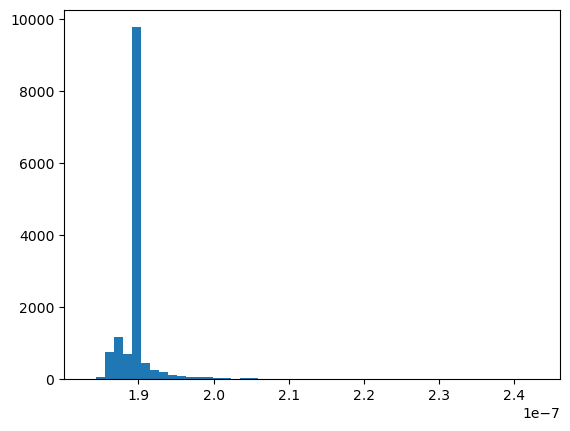

In [90]:
plt.hist(data[-1].reshape(-1,), bins=50)
plt.show()

In [138]:
clipped_p95 = np.clip(data[-1], a_min=0, a_max = np.quantile(data[-1], .95))
clipped_p99 = np.clip(data[-1], a_min=0, a_max = np.quantile(data[-1], .99))

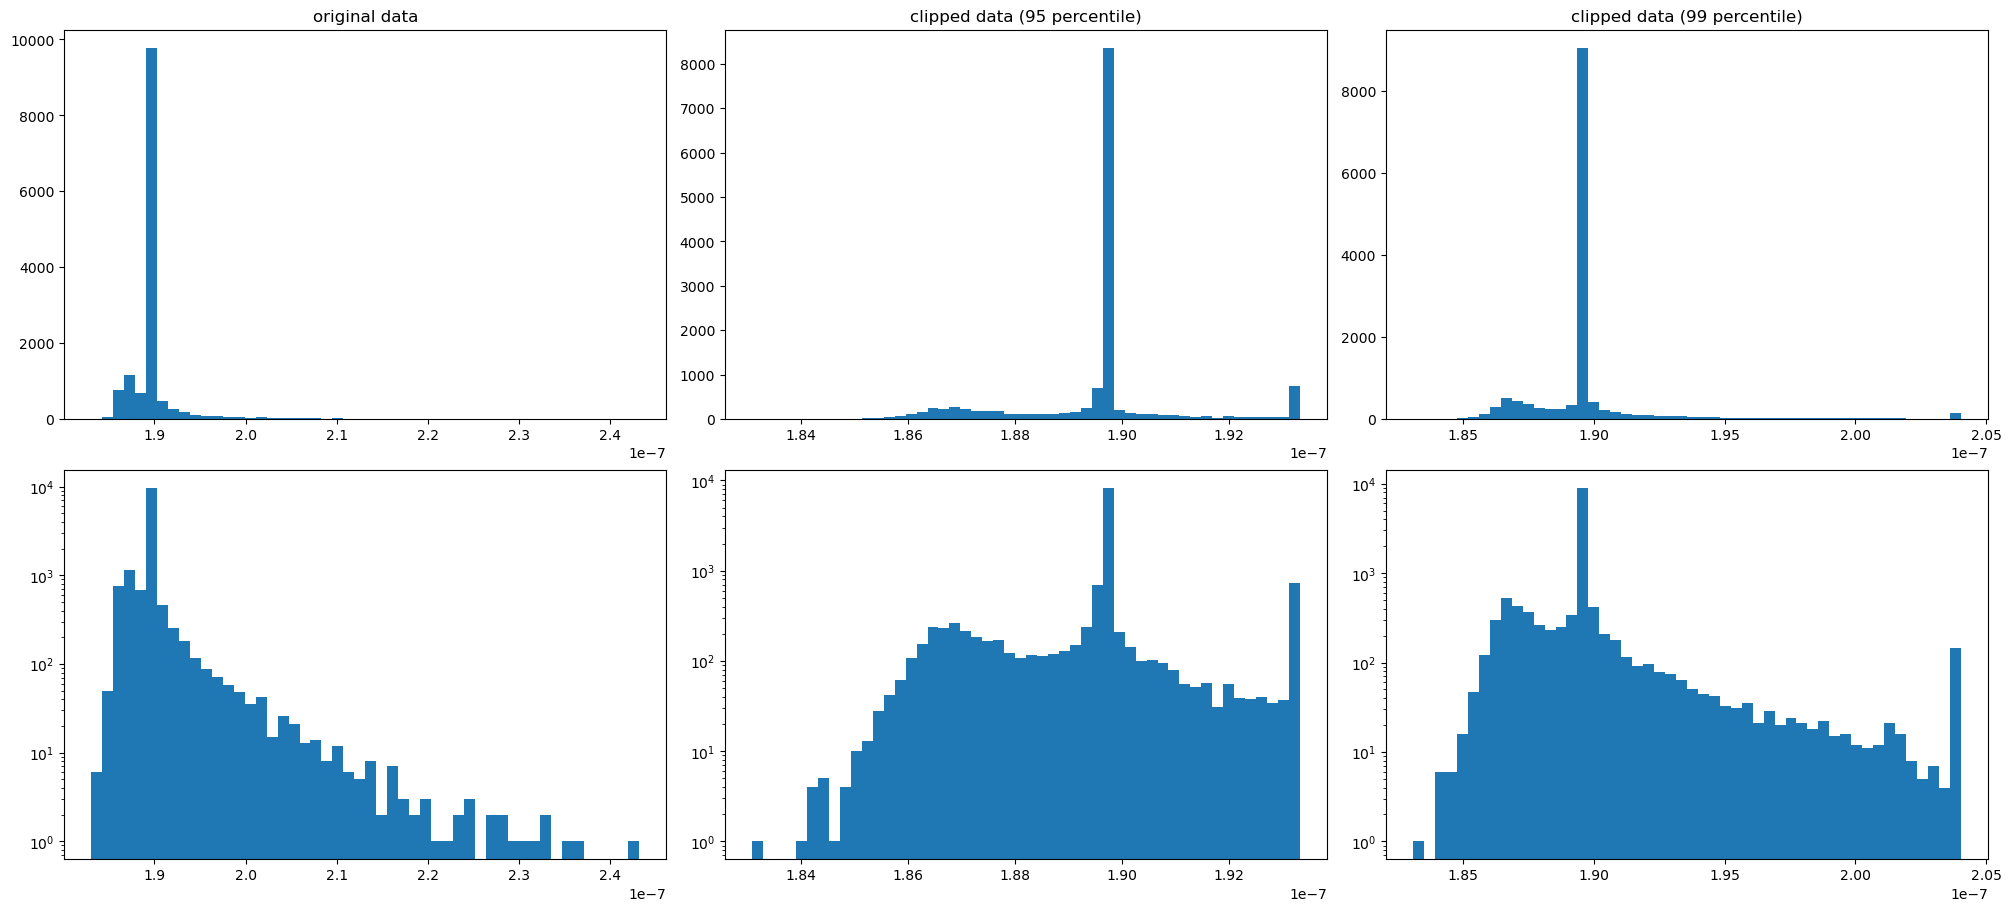

In [184]:
fig, ax = plt.subplots(2,3, figsize=(20,9), constrained_layout=True)
ax[0,0].hist(data[-1].reshape(-1,), bins=50)
ax[0,1].hist(clipped_p95.reshape(-1,), bins=50)
ax[0,2].hist(clipped_p99.reshape(-1,), bins=50)

ax[1,0].hist(data[-1].reshape(-1,), bins=50)
ax[1,1].hist(clipped_p95.reshape(-1,), bins=50)
ax[1,2].hist(clipped_p99.reshape(-1,), bins=50)
ax[1,0].set_yscale("log")
ax[1,1].set_yscale("log")
ax[1,2].set_yscale("log")

ax[0,0].set_title('original data')
ax[0,1].set_title('clipped data (95 percentile)')
ax[0,2].set_title('clipped data (99 percentile)')
# plt.tight_layout()
plt.show()

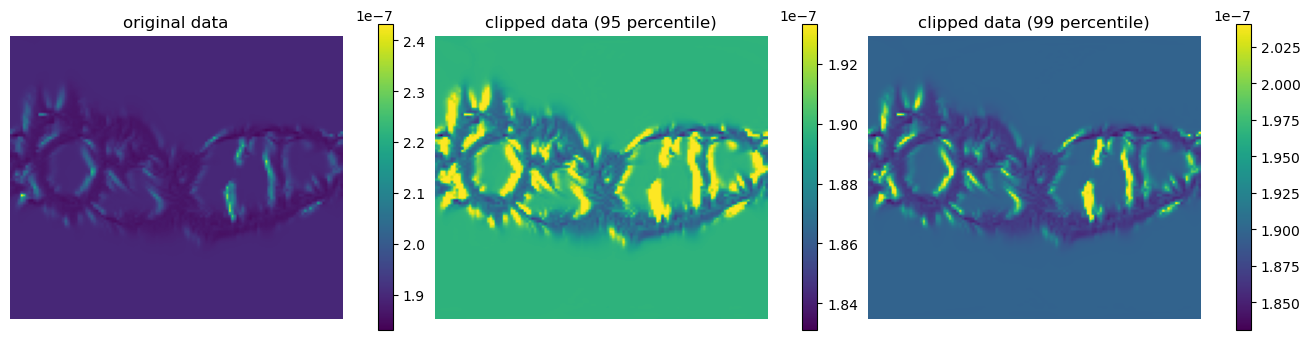

In [142]:
fig, ax = plt.subplots(1,3, figsize=(13,6), constrained_layout=True)
im0 = ax[0].imshow(data[-1], cmap='viridis')
im1 = ax[1].imshow(clipped_p95, cmap='viridis')
im2 = ax[2].imshow(clipped_p99, cmap='viridis')
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
fig.colorbar(im0, ax=ax[0], shrink=0.65, fraction=0.046, pad=0.04)
fig.colorbar(im1, ax=ax[1], shrink=0.65, fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=ax[2], shrink=0.65, fraction=0.046, pad=0.04)
ax[0].set_title('original data')
ax[1].set_title('clipped data (95 percentile)')
ax[2].set_title('clipped data (99 percentile)')
# plt.tight_layout()
plt.show()

In [152]:
import os
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Transform definitions
# --------------------------------------------------

transforms_dict = [
    {"transform": "sqrt"},
    {"transform": "log"},
    {"transform": "arcsinh"},
    {"transform": "sinh_arcsinh", "delta": 1, "epsilon": 0},
    # {"transform": "sinh_arcsinh", "delta": 2, "epsilon": 0},
    # {"transform": "sinh_arcsinh", "delta": 0.5, "epsilon": 0},
    # {"transform": "sinh_arcsinh", "delta": 1.5, "epsilon": 0},
    # {"transform": "sinh_arcsinh", "delta": 1, "epsilon": 1},
    # {"transform": "sinh_arcsinh", "delta": 1, "epsilon": -1},
]

component_list = ["vt", "vp", "bt", "bp", "jt", "jp", "jr", "rho", "p"]

component_indices = {
    "vt": 2,
    "vp": 3,
    "bt": 4,
    "bp": 5,
    "jt": 6,
    "jp": 7,
    "jr": 8,
    "rho": 9,
    "p": 10,
}


def signed_sqrt_transform(array):
    return np.sign(array) * (np.abs(array) ** 0.5)


def signed_pow_transform(array, power):
    return np.sign(array) * (np.abs(array) ** power)


def signed_log_transform(array):
    return np.sign(array) * np.log1p(np.abs(array))


def arcsinh_transform(array):
    return np.arcsinh(array)


def sinh_arcsinh_transform(array, epsilon=0.0, delta=1.0):
    return np.sinh(delta * np.arcsinh(array) - epsilon)


def signed_transform(array, transform="sqrt", power=None, epsilon=0.0, delta=1.0):
    if transform == "sqrt":
        return signed_sqrt_transform(array)

    elif transform == "log":
        return signed_log_transform(array)

    elif transform == "pow" and power is not None:
        return signed_pow_transform(array, power)

    elif transform == "arcsinh":
        return arcsinh_transform(array)

    elif transform == "sinh_arcsinh":
        return sinh_arcsinh_transform(array, epsilon=epsilon, delta=delta)

    else:
        raise ValueError(
            f"Unsupported transform={transform} or missing power for pow."
        )

def data_clip(data):
    return np.clip(data, a_min=0, a_max = np.quantile(data, .99))

def data_transformation(array, transform="sqrt", power=None, epsilon=0.0, delta=1.0):
    """
    array shape: (11, H, W)
    Returns transformed array with same shape.
    """

    new_arr = array.copy()

    # Apply selected transform to signed components
    transform_channels = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

    for ch in transform_channels:
        new_arr[ch] = signed_transform(
            array[ch],
            transform=transform,
            power=power,
            epsilon=epsilon,
            delta=delta,
        )

    # Pressure channel: fixed fourth-root transform
    new_arr[10] = signed_transform(
        data_clip(array[10]),
        transform="pow",
        power=0.25,
    )

    return new_arr

In [154]:
tf_len = len(transforms_dict)

tf_data = np.zeros((tf_len + 1, *data.shape), dtype=data.dtype)
tf_data[0] = data.copy()

for idx, tf_item in enumerate(transforms_dict):
    tf_data[idx + 1] = data_transformation(
        data,
        transform=tf_item["transform"],
        epsilon=tf_item.get("epsilon", 0),
        delta=tf_item.get("delta", 1),
    )

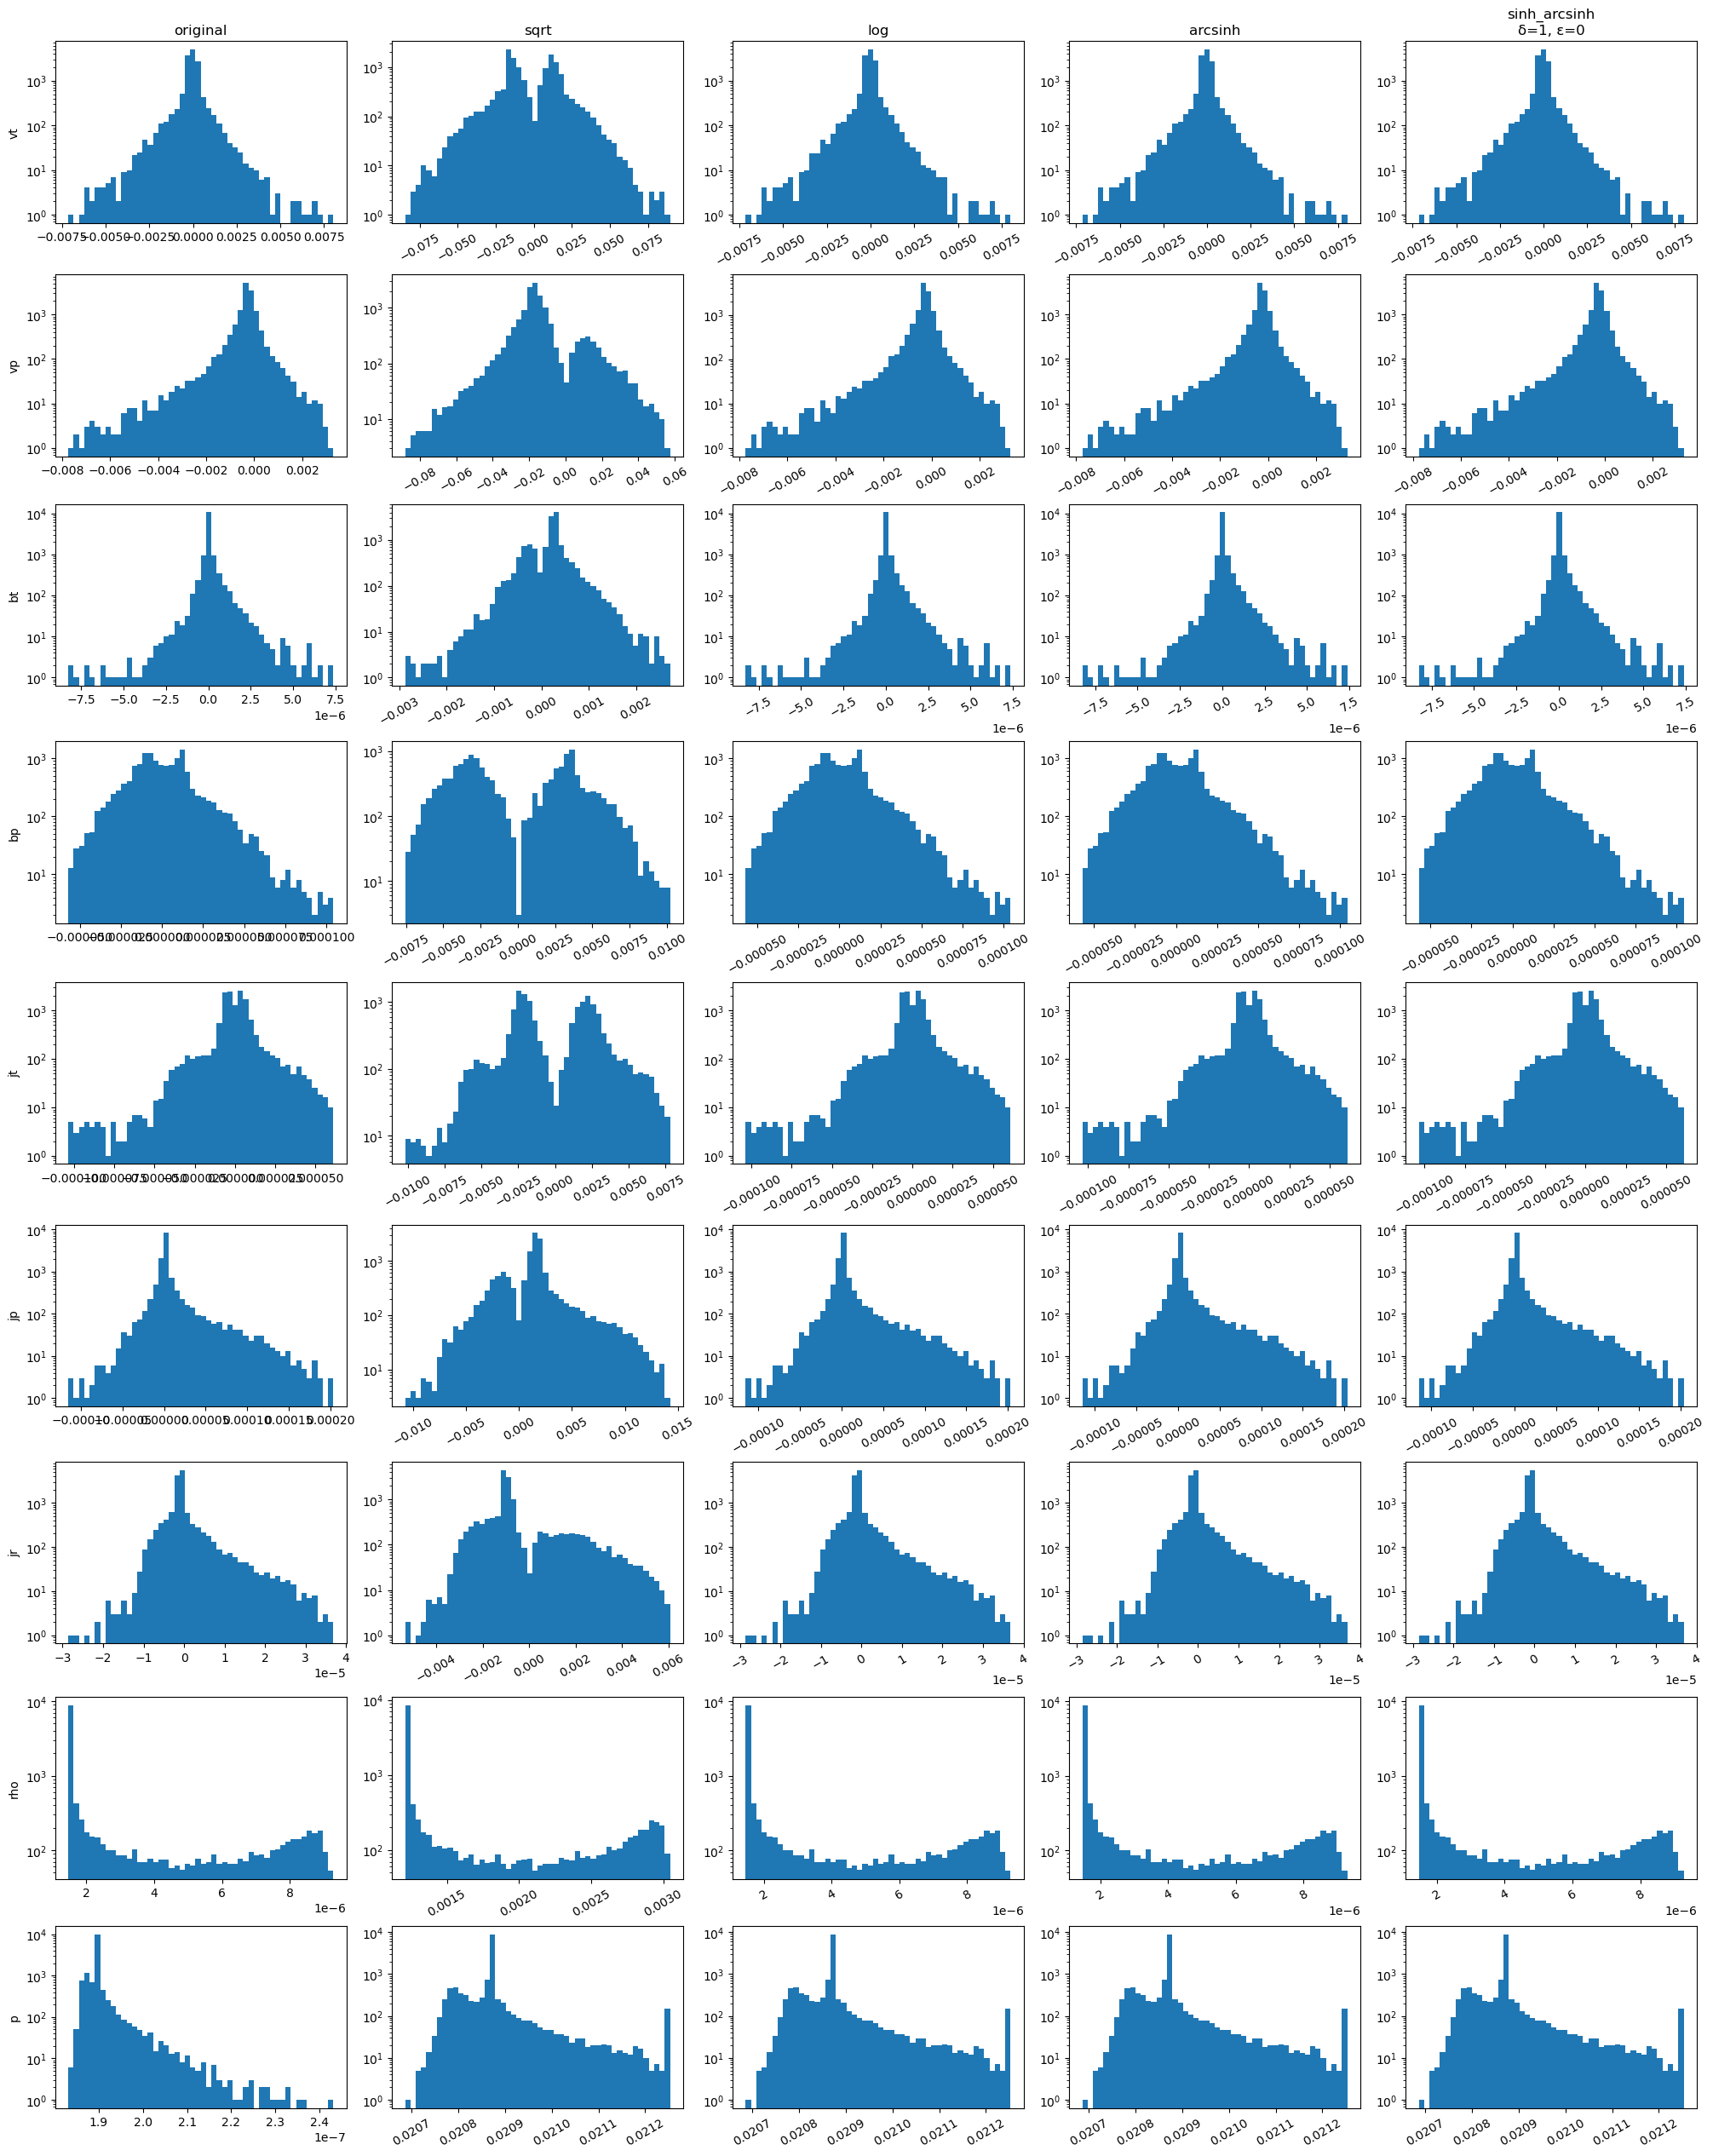

In [162]:
n_rows = len(component_list)
n_cols = tf_len + 1

fig, ax = plt.subplots(
    n_rows,
    n_cols,
    figsize=(4 * n_cols, 2.8 * n_rows),
    constrained_layout=True,
)

for row, component in enumerate(component_list):
    comp_idx = component_indices[component]

    # Original
    values = tf_data[0, comp_idx].reshape(-1)

    ax[row, 0].hist(values, bins=50)
    ax[row, 0].set_title("original" if row == 0 else "")
    ax[row, 0].set_ylabel(component)
    ax[row, 0].set_yscale("log")
    # Transforms
    for t_idx, tf_item in enumerate(transforms_dict):
        col = t_idx + 1

        transform_name = tf_item["transform"]
        ax[row, col].set_yscale("log")
        
        if transform_name == "sinh_arcsinh":
            title = (
                f"sinh_arcsinh\n"
                f"δ={tf_item.get('delta', 1)}, ε={tf_item.get('epsilon', 0)}"
            )
        else:
            title = transform_name

        values = tf_data[t_idx + 1, comp_idx].reshape(-1)

        ax[row, col].hist(values, bins=50)

        if row == 0:
            ax[row, col].set_title(title)

        # Optional: make plots cleaner
        ax[row, col].tick_params(axis="x", rotation=30)

# plt.savefig("./distribution/histograms_transforms.pdf", dpi=300, bbox_inches="tight")
# plt.savefig("./distribution/histograms_transforms.png", dpi=300, bbox_inches="tight")
plt.show()